# Migration Network Analysis

Goal:
- Which countries are migration hubs?
- Which countries are transit hubs?
- What does the global migration network look like?

In [1]:
# 01 Check venv
import sys
print(sys.executable)

/Users/andreasgilling/Documents/GitHub/german-migration-analysis/venv/bin/python


In [2]:
%pip install networkx


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
# 02 Config
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

plt.style.use("default")
sns.set_style("whitegrid")

In [4]:
# 03 Load network dataset
df_network = pd.read_csv("../data/processed/migration_network_flows_wo_ungeklärt.csv")

df_network.head()

,year,origin,destination,migrants
0,2000,Afghanistan,Germany,13.0
1,2000,Albanien,Germany,45.0
2,2000,Algerien,Germany,64.0
3,2000,Andorra,Germany,12.0
4,2000,Angola,Germany,17.0


In [5]:
df_network.shape

(5798, 4)

In [6]:
df_network.info()

<class 'pandas.DataFrame'>
RangeIndex: 5798 entries, 0 to 5797
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   year         5798 non-null   int64  
 1   origin       5798 non-null   str    
 2   destination  5798 non-null   str    
 3   migrants     5798 non-null   float64
dtypes: float64(1), int64(1), str(2)
memory usage: 181.3 KB


In [7]:
df_network.describe()

,year,migrants
count,5798.000000,5798.000000
mean,2011.998965,1078.260952
std,7.213901,2729.842086
min,2000.000000,0.000000
25%,2006.000000,78.000000
50%,2012.000000,256.000000
75%,2018.000000,787.000000
max,2024.000000,42657.000000


In [8]:
# unique countries
origins = df_network["origin"].unique()
destinations = df_network["destination"].unique()

countries = set(origins).union(set(destinations))

print("Number of countries:", len(countries))
print("Years:", df_network["year"].min(), "-", df_network["year"].max())

Number of countries: 119
Years: 2000 - 2024


In [9]:
# total migration flows
total_flows = df_network["migrants"].sum()
print("Total migrants in dataset:", total_flows)

Total migrants in dataset: 6251757.0


In [10]:
# create directed graph
G = nx.DiGraph()

# add edges
for _, row in df_network.iterrows():
    G.add_edge(
        row["origin"],
        row["destination"],
        weight=row["migrants"]
    )

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 119
Edges: 236


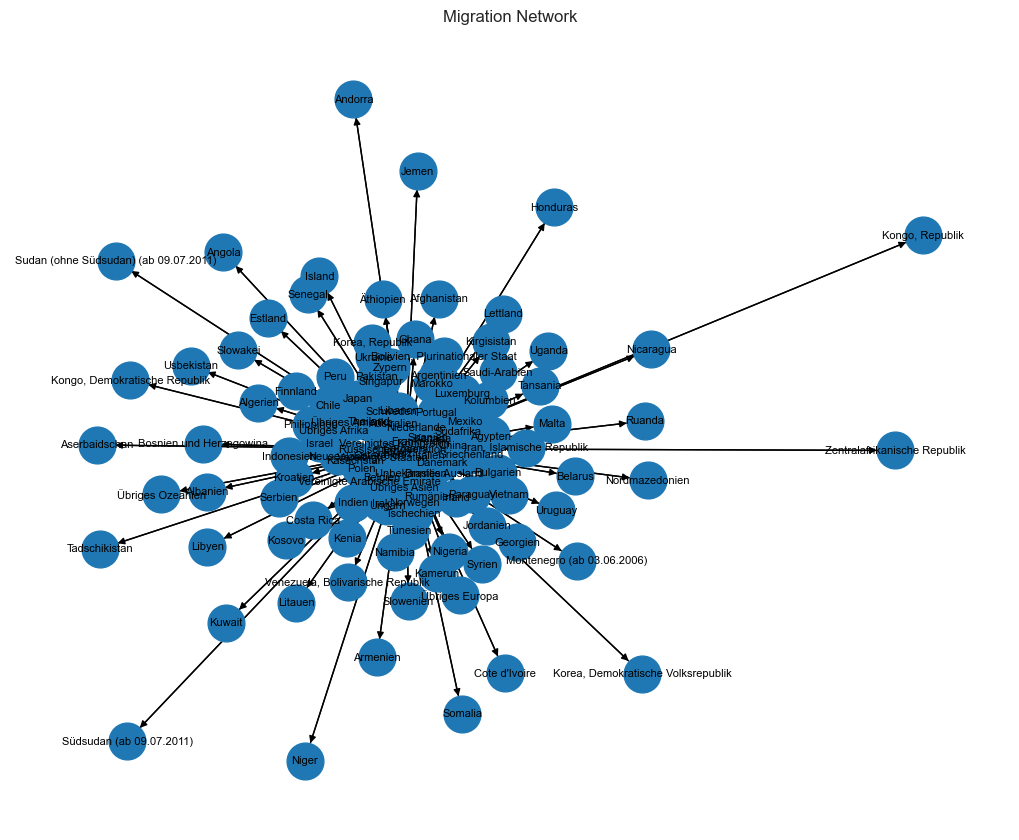

In [11]:
# Basic Network Visualization
plt.figure(figsize=(10,8))
pos = nx.spring_layout(G, seed=42)
nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=700,
    font_size=8
)
plt.title("Migration Network")
plt.show()

In [20]:
# Degree Centrality
degree_centrality = nx.degree_centrality(G)
df_degree = pd.DataFrame.from_dict(
    degree_centrality,
    orient="index",
    columns=["degree_centrality"]
)
top_degree = df_degree.sort_values(
    "degree_centrality",
    ascending=False
).head(10)

top_degree

,degree_centrality
Germany,2.000000
Montenegro (ab 03.06.2006),0.016949
Spanien,0.016949
Somalia,0.016949
Slowenien,0.016949
Slowakei,0.016949
Singapur,0.016949
Serbien,0.016949
Senegal,0.016949
Schweiz,0.016949


In [21]:
# Betweenness Centrality
betweenness = nx.betweenness_centrality(G)

df_between = pd.DataFrame.from_dict(
    betweenness,
    orient="index",
    columns=["betweenness"]
)

top_between = df_between.sort_values(
    "betweenness",
    ascending=False
).head(10)

top_between

,betweenness
Germany,1.0
Montenegro (ab 03.06.2006),0.0
Spanien,0.0
Somalia,0.0
Slowenien,0.0
Slowakei,0.0
Singapur,0.0
Serbien,0.0
Senegal,0.0
Schweiz,0.0


In [14]:
# Strongest Migration Flows
top_flows = df_network.sort_values(
    "migrants",
    ascending=False
).head(10)

top_flows

,year,origin,destination,migrants
156,2000,Kasachstan,Germany,42657.0
424,2001,Russische Föderation,Germany,42425.0
656,2002,Russische Föderation,Germany,41587.0
388,2001,Kasachstan,Germany,41212.0
192,2000,Russische Föderation,Germany,40081.0
888,2003,Russische Föderation,Germany,36280.0
620,2002,Kasachstan,Germany,33964.0
1120,2004,Russische Föderation,Germany,30931.0
1959,2008,Germany,Schweiz,29139.0
2191,2009,Germany,Schweiz,24624.0


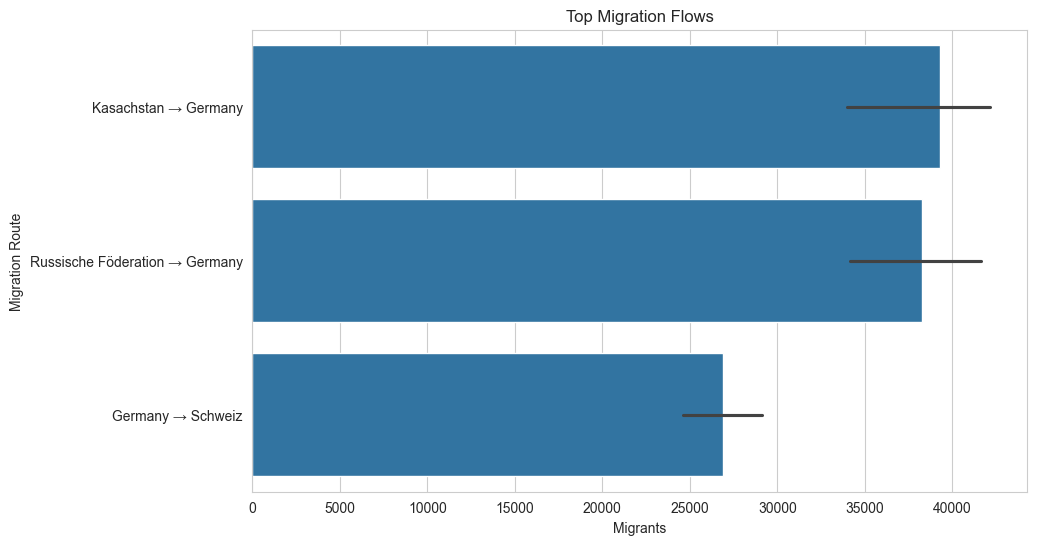

In [15]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_flows,
    x="migrants",
    y=top_flows["origin"] + " → " + top_flows["destination"]
)

plt.title("Top Migration Flows")
plt.xlabel("Migrants")
plt.ylabel("Migration Route")

plt.show()

## Network Interpretation

The migration network shows a clear hub structure.

Germany acts as the central node connecting multiple migration flows.
Countries with high degree centrality indicate strong migration ties with Germany.

Betweenness centrality highlights countries that act as important connectors
within the migration network.

The strongest migration flows reflect major migration corridors involving Germany.

In [22]:
top_degree.to_csv("../data/processed/network_degree_centrality.csv")

top_between.to_csv("../data/processed/network_betweenness_centrality.csv")